# PART II:  Error analysis  Hessian Method

In [2]:
import sys,os
import numpy as np
import scipy
from scipy.integrate import quad
from scipy.stats import kde
from scipy.stats import chi2 as spchi2
from scipy.optimize import minimize,leastsq
import matplotlib
import matplotlib.pyplot as py
import matplotlib.gridspec as gridspec
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib import rc
rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
rc('text', usetex=True)  
%matplotlib inline  
%config InlineBackend.figure_format = 'retina'
from tools import tex,save, load,fill_between,plot_hist
from tools import EVENTS,VEC4
from iminuit import Minuit,describe, Struct
import numpy.linalg as LA 
from scipy.interpolate import interp1d
from scipy.optimize import fsolve,brentq,newton,fmin

# The signal + background

Get data 

In [3]:
path='samples/sb.lhe.gz'
sb=EVENTS(path)
sb.D['m']=[]
for i in range(sb.nevents):
    particles=sb.EVENTS[i]
    for p in particles:
        if p['pid']==-13: mub=p['mom']
        elif p['pid']==13: mu=p['mom']
    z=mu+mub
    sb.D['m'].append((z*z)**0.5) 

construct observable

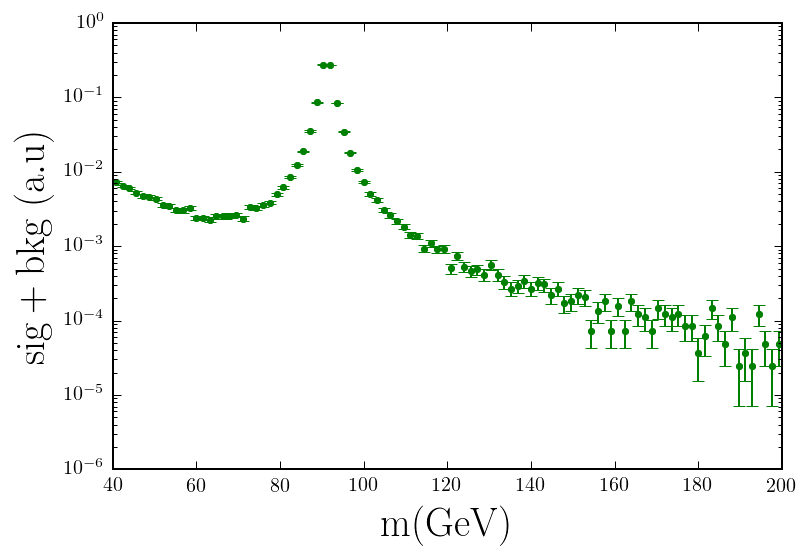

In [6]:
N,E=np.histogram(sb.D['m'],bins=100,range=(40,200))

M=0.5*(E[:-1]+E[1:])
NTOT=np.sum(N)
OBS=N/float(NTOT)
ERR=np.sqrt(N)/float(NTOT)

ax=py.subplot(111)
ax.errorbar(M,OBS,yerr=ERR,fmt='g.')
ax.set_ylabel(tex(r'sig+bkg~(a.u)'),size=20)
ax.set_xlabel(tex(r'm (GeV)'),size=20)
ax.semilogy();

make fit

In [7]:
model_sig = lambda p,m: p[0]/((m**2-p[1]**2)**2+(p[2]*p[1])**2) 
model_bkg = lambda p,m: p[3]/m**(p[4]+4) 

model_sb  = lambda p,m: model_sig(p,m)+model_bkg(p,m)
res=lambda p: (OBS-model_sb(p,M))/ERR
fit=leastsq(res,[1,90,1,1,1],full_output=1)
popt=fit[0]
res0=res(popt)
chi2=np.dot(res0,res0)
print chi2/(len(res0)-len(popt))

1.60321082041


/usr/lib/python2.7/site-packages/IPython/kernel/__main__.py:2: RuntimeWarning: divide by zero encountered in divide
  from IPython.kernel.zmq import kernelapp as app


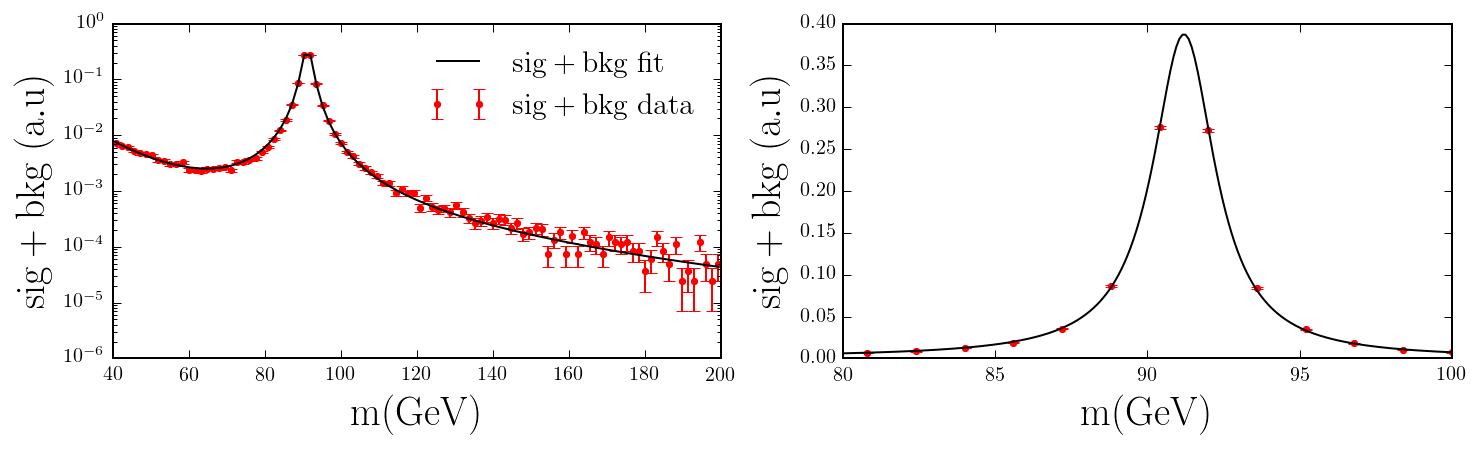

In [8]:
py.figure(figsize=(2*6,1*3))
ax=py.subplot(121)
ax.errorbar(M,OBS,yerr=ERR,fmt='r.',label=tex('sig+bkg~data'))
ax.plot(M,model_sb(popt,M),'k-',label=tex('sig+bkg~fit'))
ax.set_ylabel(tex(r'sig+bkg~(a.u)'),size=20)
ax.set_xlabel(tex(r'm (GeV)'),size=20)
ax.semilogy();
ax.legend(fontsize=15,frameon=0)

ax=py.subplot(122)
ax.errorbar(M,OBS,yerr=ERR,fmt='r.',label=tex('sig+bkg~data'))
M0=np.linspace(80,100,200)
ax.plot(M0,model_sb(popt,M0),'k-',label=tex('sig+bkg~fit'))
ax.set_xlim(np.amin(M0),np.amax(M0))
ax.set_ylabel(tex(r'sig+bkg~(a.u)'),size=20)
ax.set_xlabel(tex(r'm (GeV)'),size=20)

# Hessian error propagation

Get eigen directions 

In [9]:
popt, pcov, infodict, errmsg, ier = fit
s_sq = (infodict['fvec']**2).sum()/M.size  
cov = pcov * s_sq 
W,V=LA.eig(cov)
V=np.transpose(V)
for i in range(W.size): V[i]*=np.sqrt(W[i])

get $\chi^2$ along eigen directions

In [10]:
get_chi2 = lambda p:np.sum(res(p)**2)
T=np.linspace(-10,10,100)
CHI2=np.zeros((W.size,T.size))
for i in range(W.size):
    CHI2[i]=np.array([get_chi2(popt+t*V[i]) for t in T])

plot $\chi^2$ vs T

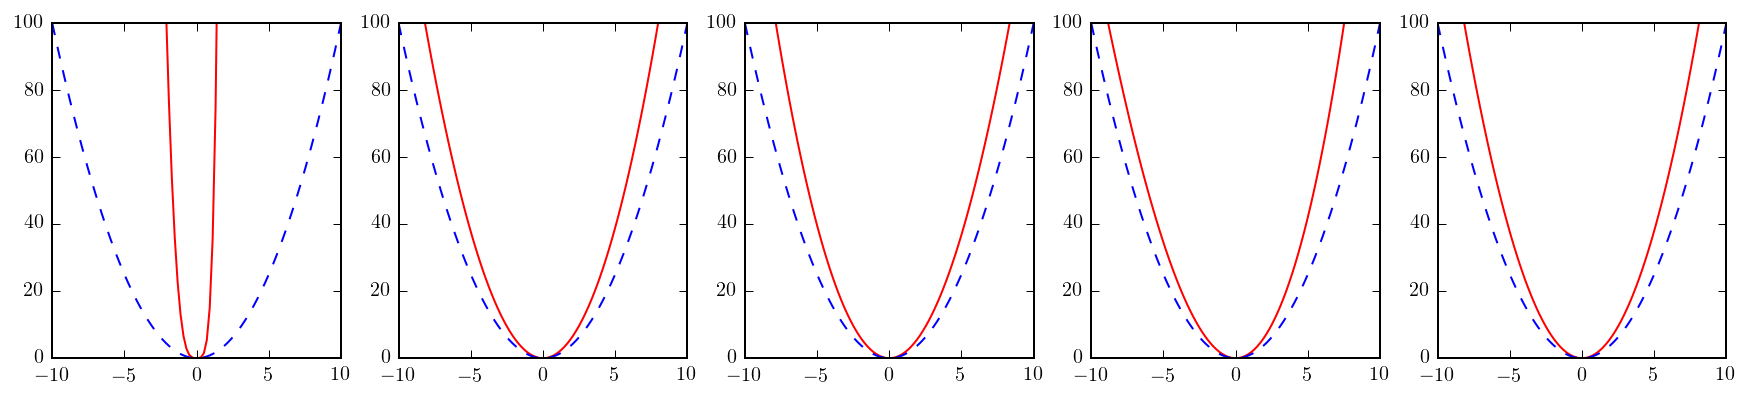

In [11]:
py.figure(figsize=(3*5,3*1))
for i in range(5):
    ax=py.subplot(1,5,i+1)
    ax.plot(T,CHI2[i]-np.amin(CHI2[i]),'r-')
    ax.set_ylim(0,100)
    ax.plot(T,T*T,'b--')

In [12]:
def get_CL(T,CHI2):
    f = interp1d(T,CHI2,kind='cubic')
    t0=fmin(lambda t:f(t),0,disp=0)[0]
    pdf=lambda t: np.exp(-0.5*(f(t)-f(t0)))
    norm=quad(pdf,np.amin(T[0]),np.amax(T[-1]))[0]
    pdf=lambda t: np.exp(-0.5*(f(t)-f(t0)))/norm
    cdf=lambda tlims: quad(pdf,tlims[0],tlims[1])[0]
   
    def get_tlims(h):
        tR=brentq(lambda t:pdf(t)-h, t0,np.amax(T))
        tL=brentq(lambda t:pdf(t)-h, np.amin(T),t0)
        return [tL,tR]
    
    h68=brentq(lambda h:cdf(get_tlims(h))-0.68,pdf(t0)/10,pdf(t0))
    tlim68=get_tlims(h68)
    
    h95=brentq(lambda h:cdf(get_tlims(h))-0.95,pdf(t0)/10,pdf(t0))
    tlim95=get_tlims(h95)

    return {'tlim68':tlim68,'tlim95':tlim95,'pdf':pdf}

In [36]:
CL={}
for i in range(W.size):
    CL[i]=get_CL(T,CHI2[i])
    print CL[i]['tlim68']

[-0.39670206722138285, 0.35755628497258485]
[-0.8040400539967497, 0.8021531125591577]
[-0.8021973207757453, 0.8068702402257164]
[-0.8125319059125629, 0.7996928282666728]
[-0.8083641276659184, 0.8078643132010894]


In [37]:
def get_error(obs):
    D={}
    D['+'] = np.zeros(obs[0].size)
    for k in obs.keys():
        if k<=0: continue
        diff=np.zeros((3,obs[0].size))
        diff[0]= obs[k]-obs[0]
        diff[1]= obs[-k]-obs[0]
        D['+']+=np.amax(diff,axis=0)**2
    D['+']=D['+']**0.5

    D['-'] = np.zeros(obs[0].size)
    for k in obs.keys():
        if k<=0: continue
        diff=np.zeros((3,obs[0].size))
        diff[0]= -obs[k]+obs[0]
        diff[1]= -obs[-k]+obs[0]
        D['-']+=np.amax(diff,axis=0)**2
    D['-']=D['-']**0.5
    obs['+'] = D['+']
    obs['-'] = D['-']
    return obs

In [41]:
M0=np.linspace(40,200,100)
THY={0:model_sb(popt,M0)}
for i in range(W.size):
    pm = popt + CL[i]['tlim68'][0]*V[i] 
    pp = popt + CL[i]['tlim68'][1]*V[i]
    k=i+1
    THY[-k]= model_sb(pm,M0)
    THY[k] = model_sb(pp,M0)

THY=get_error(THY)

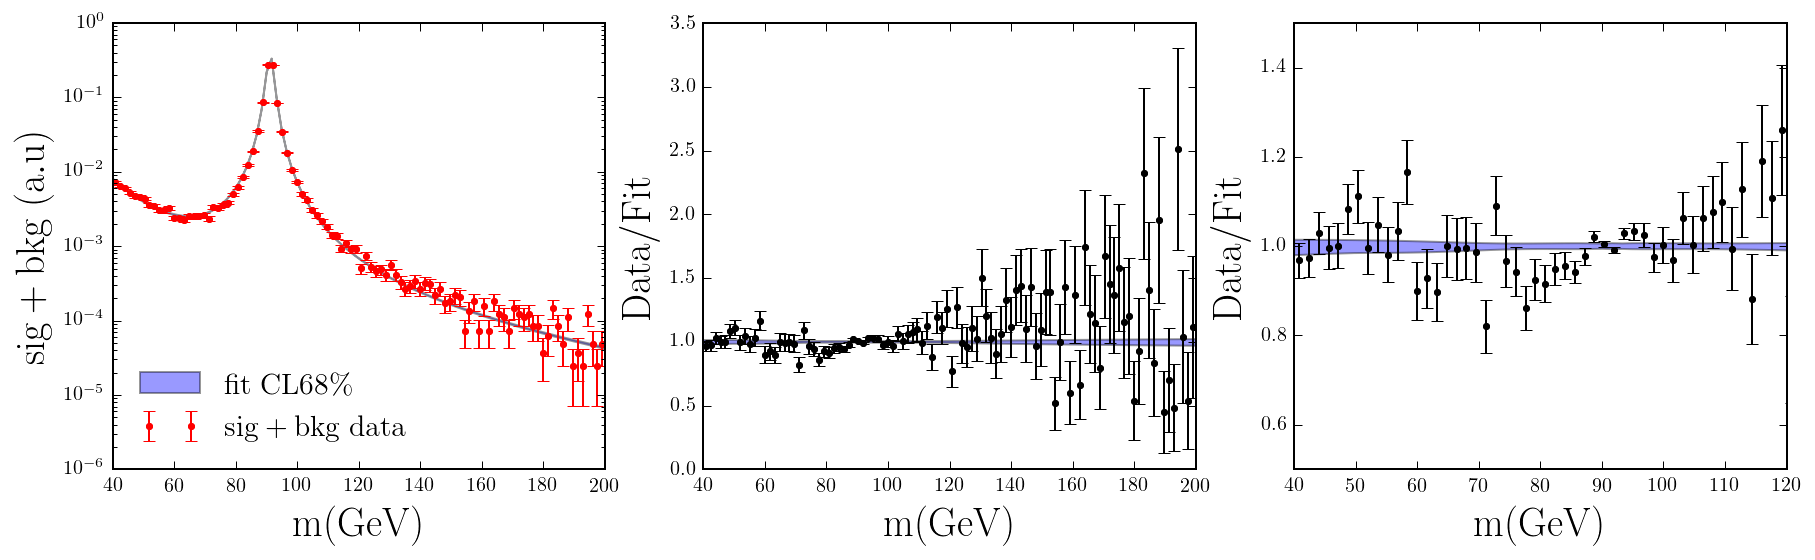

In [60]:
py.figure(figsize=(5*3,4*1))

ax=py.subplot(131)
ax.errorbar(M,OBS,yerr=ERR,fmt='r.',label=tex('sig+bkg~data'))
ax.semilogy()
Ym=THY[0]-THY['-']
Yp=THY[0]+THY['+']
fill_between(M0,y1=Ym,y2=Yp, ax=ax, facecolor='b',alpha=0.4,label=tex('fit~CL68\%'))
ax.legend(fontsize=15,frameon=0,loc=3)
ax.set_ylabel(tex(r'sig+bkg~(a.u)'),size=20)
ax.set_xlabel(tex(r'm (GeV)'),size=20)

ax=py.subplot(132)
Ym/=THY[0]
Yp/=THY[0]
fill_between(M0,y1=Ym,y2=Yp, ax=ax, facecolor='b',alpha=0.4,label='fit~CL68\%')
ax.errorbar(M,OBS/model_sb(popt,M),yerr=ERR/model_sb(popt,M),fmt='k.')
ax.set_ylabel(tex(r'Data/Fit'),size=20)
ax.set_xlabel(tex(r'm (GeV)'),size=20)


ax=py.subplot(133)
fill_between(M0,y1=Ym,y2=Yp, ax=ax, facecolor='b',alpha=0.4,label='fit~CL68\%')
ax.errorbar(M,OBS/model_sb(popt,M),yerr=ERR/model_sb(popt,M),fmt='k.')
ax.set_xlim(40,120)
ax.set_ylim(0.5,1.5);
ax.set_ylabel(tex(r'Data/Fit'),size=20)
ax.set_xlabel(tex(r'm (GeV)'),size=20)